In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("GPU available:", torch.cuda.is_available())

transform = transforms.Compose([transforms.ToTensor()])
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

class EmbeddingNet(nn.Module):
    def __init__(self, embedding_dim=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.fc = nn.Linear(128*4*4, embedding_dim)

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        x = nn.functional.normalize(x, p=2, dim=1)
        return x

model_embed = EmbeddingNet().to(device)
print("GPU check + model ready")

GPU available: True


100%|██████████| 170M/170M [34:11<00:00, 83.1kB/s] 


GPU check + model ready


In [5]:
def get_semi_hard_triplets(embeddings, labels, margin):
    dist_matrix = torch.cdist(embeddings, embeddings, p=2)
    triplets = []
    labels_np = labels.cpu().numpy()

    for i in range(len(labels)):
        anchor_label = labels_np[i]
        pos_mask = (labels_np == anchor_label)
        pos_mask[i] = False
        neg_mask = (labels_np != anchor_label)

        if pos_mask.sum() == 0 or neg_mask.sum() == 0:
            continue

        pos_indices = np.where(pos_mask)[0]
        pos_idx = pos_indices[np.random.randint(len(pos_indices))]
        d_ap = dist_matrix[i, pos_idx].item()

        neg_indices = np.where(neg_mask)[0]
        neg_dists = dist_matrix[i, neg_indices]

        semi_hard_mask = (neg_dists > d_ap) & (neg_dists < d_ap + margin)
        if semi_hard_mask.sum() > 0:
            candidates = neg_indices[semi_hard_mask.cpu().numpy()]
            neg_idx = candidates[np.random.randint(len(candidates))]
        else:
            neg_idx = neg_indices[torch.argmin(neg_dists).item()]

        triplets.append((i, pos_idx, neg_idx))
    return triplets

def triplet_loss_batch(embeddings, triplets, margin):
    losses = []
    for a, p, n in triplets:
        d_ap = torch.norm(embeddings[a] - embeddings[p], p=2)
        d_an = torch.norm(embeddings[a] - embeddings[n], p=2)
        loss = torch.clamp(d_ap - d_an + margin, min=0)
        losses.append(loss)
    return torch.stack(losses).mean() if losses else torch.tensor(0.0, device=embeddings.device)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False)

optimizer_embed = optim.Adam(model_embed.parameters(), lr=0.001)
margin = 0.3

for epoch in range(15):
    model_embed.train()
    running_loss = 0.0
    batch_count = 0
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        embeddings = model_embed(images)

        triplets = get_semi_hard_triplets(embeddings, labels, margin)
        if len(triplets) == 0:
            continue

        loss = triplet_loss_batch(embeddings, triplets, margin)

        optimizer_embed.zero_grad()
        loss.backward()
        optimizer_embed.step()
        running_loss += loss.item()
        batch_count += 1

    print(f"Epoch {epoch+1}/15, Loss: {running_loss/batch_count:.4f}")

Epoch 1/15, Loss: 0.1647
Epoch 2/15, Loss: 0.1520
Epoch 3/15, Loss: 0.1490
Epoch 4/15, Loss: 0.1441
Epoch 5/15, Loss: 0.1407
Epoch 6/15, Loss: 0.1378
Epoch 7/15, Loss: 0.1347
Epoch 8/15, Loss: 0.1330
Epoch 9/15, Loss: 0.1307
Epoch 10/15, Loss: 0.1277
Epoch 11/15, Loss: 0.1252
Epoch 12/15, Loss: 0.1237
Epoch 13/15, Loss: 0.1213
Epoch 14/15, Loss: 0.1192
Epoch 15/15, Loss: 0.1173


In [6]:
def get_embeddings(model, loader):
    model.eval()
    all_embeddings = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            emb = model(images)
            all_embeddings.append(emb.cpu())
            all_labels.append(labels)
    return torch.cat(all_embeddings), torch.cat(all_labels)

def knn_accuracy(embeddings, labels, k=5):
    dist_matrix = torch.cdist(embeddings, embeddings, p=2)
    dist_matrix.fill_diagonal_(float('inf'))  # exclude self-match
    _, nearest_idx = torch.topk(dist_matrix, k, largest=False, dim=1)

    correct = 0
    for i in range(len(labels)):
        neighbor_labels = labels[nearest_idx[i]]
        majority_vote = torch.mode(neighbor_labels).values.item()
        if majority_vote == labels[i].item():
            correct += 1
    return 100 * correct / len(labels)

# Learned embedding KNN accuracy
test_embeddings, test_labels = get_embeddings(model_embed, testloader)
learned_acc = knn_accuracy(test_embeddings, test_labels, k=5)
print(f"Learned embedding KNN accuracy (k=5): {learned_acc:.2f}%")

# Raw pixel baseline KNN accuracy
raw_images = []
raw_labels = []
for images, labels in testloader:
    raw_images.append(images.view(images.size(0), -1))  # flatten to raw pixel vectors
    raw_labels.append(labels)
raw_images = torch.cat(raw_images)
raw_labels = torch.cat(raw_labels)

pixel_acc = knn_accuracy(raw_images, raw_labels, k=5)
print(f"Raw pixel KNN accuracy (k=5): {pixel_acc:.2f}%")

Learned embedding KNN accuracy (k=5): 67.20%
Raw pixel KNN accuracy (k=5): 28.72%


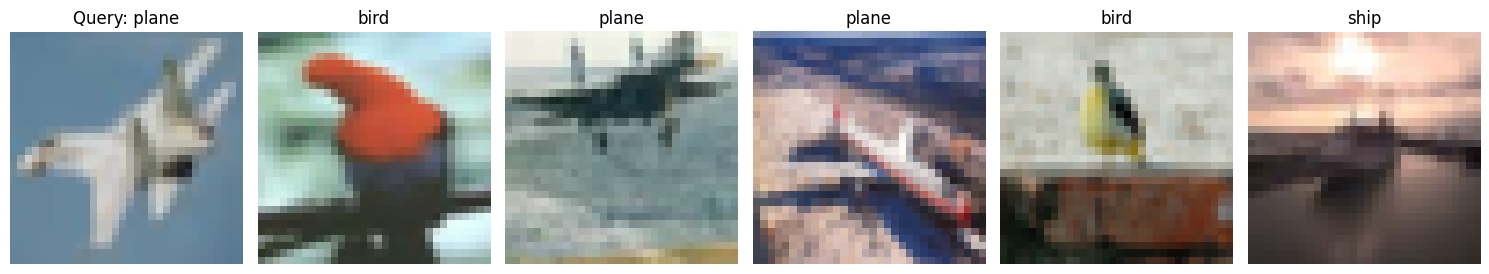

In [7]:
def show_retrieval(query_idx, embeddings, labels, images_dataset, k=5):
    dist_matrix = torch.cdist(embeddings[query_idx:query_idx+1], embeddings, p=2)
    dist_matrix[0, query_idx] = float('inf')
    _, nearest_idx = torch.topk(dist_matrix, k, largest=False, dim=1)
    nearest_idx = nearest_idx[0].numpy()

    fig, axes = plt.subplots(1, k+1, figsize=(15, 3))
    query_img, query_label = images_dataset[query_idx]
    axes[0].imshow(query_img.permute(1,2,0))
    axes[0].set_title(f"Query: {classes[query_label]}")
    axes[0].axis('off')

    for i, idx in enumerate(nearest_idx):
        img, label = images_dataset[idx]
        axes[i+1].imshow(img.permute(1,2,0))
        axes[i+1].set_title(classes[label])
        axes[i+1].axis('off')

    plt.tight_layout()
    plt.show()

show_retrieval(query_idx=10, embeddings=test_embeddings, labels=test_labels, images_dataset=testset, k=5)

In [8]:
def get_random_triplets(embeddings, labels):
    labels_np = labels.cpu().numpy()
    triplets = []
    for i in range(len(labels)):
        anchor_label = labels_np[i]
        pos_mask = (labels_np == anchor_label)
        pos_mask[i] = False
        neg_mask = (labels_np != anchor_label)
        if pos_mask.sum() == 0 or neg_mask.sum() == 0:
            continue
        pos_idx = np.where(pos_mask)[0][np.random.randint(pos_mask.sum())]
        neg_idx = np.where(neg_mask)[0][np.random.randint(neg_mask.sum())]
        triplets.append((i, pos_idx, neg_idx))
    return triplets

model_embed_random = EmbeddingNet().to(device)
optimizer_random = optim.Adam(model_embed_random.parameters(), lr=0.001)
margin = 0.3

for epoch in range(15):
    model_embed_random.train()
    running_loss = 0.0
    batch_count = 0
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        embeddings = model_embed_random(images)

        triplets = get_random_triplets(embeddings, labels)
        if len(triplets) == 0:
            continue

        loss = triplet_loss_batch(embeddings, triplets, margin)

        optimizer_random.zero_grad()
        loss.backward()
        optimizer_random.step()
        running_loss += loss.item()
        batch_count += 1

    print(f"Epoch {epoch+1}/15, Loss: {running_loss/batch_count:.4f}")

Epoch 1/15, Loss: 0.1944
Epoch 2/15, Loss: 0.1621
Epoch 3/15, Loss: 0.1444
Epoch 4/15, Loss: 0.1344
Epoch 5/15, Loss: 0.1258
Epoch 6/15, Loss: 0.1198
Epoch 7/15, Loss: 0.1117
Epoch 8/15, Loss: 0.1077
Epoch 9/15, Loss: 0.1040
Epoch 10/15, Loss: 0.0981
Epoch 11/15, Loss: 0.0949
Epoch 12/15, Loss: 0.0922
Epoch 13/15, Loss: 0.0888
Epoch 14/15, Loss: 0.0869
Epoch 15/15, Loss: 0.0829


In [9]:
random_test_embeddings, random_test_labels = get_embeddings(model_embed_random, testloader)
random_acc = knn_accuracy(random_test_embeddings, random_test_labels, k=5)
print(f"Random-negative model KNN accuracy (k=5): {random_acc:.2f}%")
print(f"Semi-hard mining model KNN accuracy (k=5): {learned_acc:.2f}%")
print(f"Raw pixel baseline KNN accuracy (k=5): {pixel_acc:.2f}%")

Random-negative model KNN accuracy (k=5): 67.44%
Semi-hard mining model KNN accuracy (k=5): 67.20%
Raw pixel baseline KNN accuracy (k=5): 28.72%


In [10]:
trainloader_big = torch.utils.data.DataLoader(trainset, batch_size=512, shuffle=True)

model_embed_bigbatch = EmbeddingNet().to(device)
optimizer_bigbatch = optim.Adam(model_embed_bigbatch.parameters(), lr=0.001)
margin = 0.3

for epoch in range(15):
    model_embed_bigbatch.train()
    running_loss = 0.0
    batch_count = 0
    for images, labels in trainloader_big:
        images, labels = images.to(device), labels.to(device)
        embeddings = model_embed_bigbatch(images)

        triplets = get_semi_hard_triplets(embeddings, labels, margin)
        if len(triplets) == 0:
            continue

        loss = triplet_loss_batch(embeddings, triplets, margin)

        optimizer_bigbatch.zero_grad()
        loss.backward()
        optimizer_bigbatch.step()
        running_loss += loss.item()
        batch_count += 1

    print(f"Epoch {epoch+1}/15, Loss: {running_loss/batch_count:.4f}")

Epoch 1/15, Loss: 0.1655
Epoch 2/15, Loss: 0.1575
Epoch 3/15, Loss: 0.1512
Epoch 4/15, Loss: 0.1485
Epoch 5/15, Loss: 0.1463
Epoch 6/15, Loss: 0.1424
Epoch 7/15, Loss: 0.1408
Epoch 8/15, Loss: 0.1400
Epoch 9/15, Loss: 0.1379
Epoch 10/15, Loss: 0.1366
Epoch 11/15, Loss: 0.1347
Epoch 12/15, Loss: 0.1337
Epoch 13/15, Loss: 0.1328
Epoch 14/15, Loss: 0.1309
Epoch 15/15, Loss: 0.1292


In [11]:
testloader_big = torch.utils.data.DataLoader(testset, batch_size=512, shuffle=False)
bigbatch_test_embeddings, bigbatch_test_labels = get_embeddings(model_embed_bigbatch, testloader)
bigbatch_acc = knn_accuracy(bigbatch_test_embeddings, bigbatch_test_labels, k=5)

print(f"Semi-hard mining (batch=512) KNN accuracy: {bigbatch_acc:.2f}%")
print(f"Semi-hard mining (batch=128) KNN accuracy: {learned_acc:.2f}%")
print(f"Random negative (batch=128) KNN accuracy: {random_acc:.2f}%")
print(f"Raw pixel baseline KNN accuracy: {pixel_acc:.2f}%")

Semi-hard mining (batch=512) KNN accuracy: 64.24%
Semi-hard mining (batch=128) KNN accuracy: 67.20%
Random negative (batch=128) KNN accuracy: 67.44%
Raw pixel baseline KNN accuracy: 28.72%


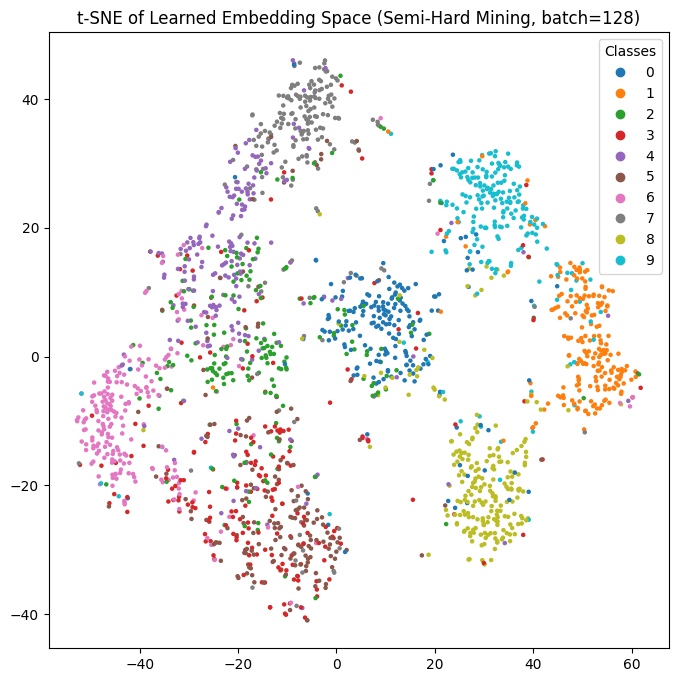

In [12]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, random_state=42)
emb_2d = tsne.fit_transform(test_embeddings[:2000].numpy())

plt.figure(figsize=(8,8))
scatter = plt.scatter(emb_2d[:,0], emb_2d[:,1], c=test_labels[:2000], cmap='tab10', s=5)
plt.legend(*scatter.legend_elements(), title="Classes", loc='best')
plt.title("t-SNE of Learned Embedding Space (Semi-Hard Mining, batch=128)")
plt.show()